# 25 · Self-RAG — retrieve-on-demand with reflection tokens

> **TL;DR.** Decide whether to retrieve; if yes, fetch top-k docs; emit **per-doc reflection tokens** (categorical `is_relevant`, `is_supported`, `is_useful`); Python composes a keep/drop boolean per doc; answer from kept docs only.
>
> **Reach for it when** you need finer-grained doc-level quality control than CRAG's whole-batch routing, and want explicit per-doc audit signals.
> **Avoid when** retrievals are usually clean (the per-doc reflection cost is wasted) or when the corpus is small enough that reflection cost dominates.

| Property | Value |
|---|---|
| Origin | Asai et al., *Self-RAG* (2024). [arXiv:2310.11511](https://arxiv.org/abs/2310.11511) |
| Reflection tokens | 3-way categorical per doc: `is_relevant`, `is_supported`, `is_useful` |
| Picker | Python composes keep/drop from token labels — deterministic-picker |
| Default LLM | Llama-3.3-70B |
| Cost | 1 decide + 1 retrieve + `top_k` reflect + 1 answer = `top_k + 3` calls |

**Why deterministic-picker is the load-bearing pattern here.** Self-RAG's reflection tokens were originally LEARNED special tokens (the paper trains a model to emit them). We simulate them via Pydantic structured output. The key fidelity-preserving move: every token is `Literal[...]` — categorical — not a numeric score. Python composes the keep/drop boolean as `is_relevant != 'not_relevant' AND is_supported != 'no_support'`.

## 2 · Architecture at a glance

```mermaid
flowchart TB
    A([task]) --> D[DECIDE_RETRIEVAL<br/><sub>bool: parametric or external?</sub>]
    D -->|False| ANS[ANSWER from parametric]
    D -->|True| R[RETRIEVE top-k]
    R --> RF[REFLECT per doc<br/><sub>3 categorical tokens per doc</sub>]
    RF --> CK[COMPOSE_KEEP<br/><sub>Python boolean per doc</sub>]
    CK --> ANS
    ANS --> Z([final])

    style RF fill:#fff3e0,stroke:#f57c00
    style CK fill:#fce4ec,stroke:#c2185b
    style ANS fill:#e8f5e9,stroke:#388e3c
```

## 3 · Theory

### 3.0 · The three reflection tokens

Per Asai et al.:
- **`is_relevant`** — does this doc address the question?
- **`is_supported`** — would using this doc produce a well-grounded answer?
- **`is_useful`** — overall usefulness signal.

Each is a 3-way categorical (`fully_X` / `partially_X` / `not_X` or `no_X`). No numeric scoring.

### 3.1 · How Python composes the keep/drop

```python
def _compose_keep(state):
    return [
        i for i, t in enumerate(state['reflection_tokens'])
        if t['is_relevant'] != 'not_relevant'
        and t['is_supported'] != 'no_support'
    ]
```

This is the deciding signal — Python AND on two categorical commitments. The LLM never emits a numeric usefulness score.

### 3.2 · Where this sits in the RAG family

| Pattern | Granularity of quality control |
|---|---|
| Plain RAG | None |
| [Agentic RAG (nb 23)](./23_agentic_rag.ipynb) | None (agent just answers) |
| [CRAG (nb 24)](./24_corrective_rag.ipynb) | Whole batch (route based on aggregate) |
| **Self-RAG (this nb)** | **Per-document** (drop individual junk docs) |
| [Adaptive RAG (nb 26)](./26_adaptive_rag.ipynb) | Per-task (no/single/multi-step routing) |

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import SelfRAG
from agentic_architectures.data import STARDUST_CORPUS
from agentic_architectures.ui import print_md, print_header

enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.2)
print_header(f"LLM: {llm.model}  ·  Corpus: {len(STARDUST_CORPUS)} docs")

LLM: meta-llama/Llama-3.3-70B-Instruct  ·  Corpus: 12 docs ────────────────────────────────────────────────────────

## 5 · Library walkthrough

In [2]:
from agentic_architectures.architectures.self_rag import _ReflectionTokens, SelfRAG
import json, inspect
print('--- _ReflectionTokens schema ---')
print(json.dumps(_ReflectionTokens.model_json_schema(), indent=2)[:700] + '...')
print()
print('--- _compose_keep (Python) ---')
print(inspect.getsource(SelfRAG._compose_keep))

--- _ReflectionTokens schema ---
{
  "description": "Per-document reflection tokens \u2014 all categorical (deterministic-picker).",
  "properties": {
    "is_relevant": {
      "description": "Does this document address the question?",
      "enum": [
        "fully_relevant",
        "partially_relevant",
        "not_relevant"
      ],
      "title": "Is Relevant",
      "type": "string"
    },
    "is_supported": {
      "description": "If you used this document as evidence, how well-grounded would the answer be?",
      "enum": [
        "fully_supported",
        "partially_supported",
        "no_support"
      ],
      "title": "Is Supported",
      "type": "string"
    },
    "is_useful": {
      "description": "Ov...

--- _compose_keep (Python) ---
    def _compose_keep(self, state: SelfRAGState) -> dict[str, Any]:
        """Python decides which docs to keep — pure deterministic-picker."""
        tokens = state.get("reflection_tokens", [])
        kept: list[int] = []
     

## 7 · Build the graph

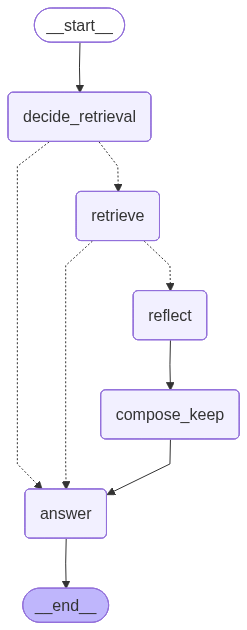

In [3]:
from IPython.display import Image, display
arch = SelfRAG(llm=llm, documents=STARDUST_CORPUS, top_k=4)
graph = arch.build()
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(mermaid PNG render unavailable: {e}; see § 2)")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — 3 tasks

1. **Direct retrieval task** — answer in corpus.
2. **Parametric task** — agent should skip retrieval.
3. **Mismatch task** — corpus has loosely-related docs but no direct answer; reflection should drop most/all docs.

In [4]:
TASKS = [
    ("direct",     "When was Stardust Aerospace founded and by whom?"),
    ("parametric", "What is 25 squared? Return only the integer."),
    ("mismatch",   "What is the boiling point of liquid nitrogen?"),
]

for tag, q in TASKS:
    r = arch.run(q)
    print(f"TASK_TAG: {tag}")
    print(f"  TASK: {q}")
    print(f"  NEEDS_RETRIEVAL: {r.metadata['needs_retrieval']}")
    print(f"  N_RETRIEVED: {r.metadata['n_retrieved']}")
    print(f"  N_KEPT: {r.metadata['n_kept']}")
    print(f"  KEPT_INDICES: {r.metadata['kept_indices']}")
    print(f"  N_FULLY_RELEVANT: {r.metadata['n_fully_relevant']}")
    print(f"  N_NO_SUPPORT: {r.metadata['n_no_support']}")
    print(f"  N_VERY_USEFUL: {r.metadata['n_very_useful']}")
    tokens = r.metadata['reflection_tokens']
    for i, t in enumerate(tokens):
        print(f"    doc[{i}]: rel={t['is_relevant']}  sup={t['is_supported']}  use={t['is_useful']}")
    print(f"  FINAL_ANSWER: {r.output[:200]}")
    print()

TASK_TAG: direct
  TASK: When was Stardust Aerospace founded and by whom?
  NEEDS_RETRIEVAL: True
  N_RETRIEVED: 4
  N_KEPT: 1
  KEPT_INDICES: [0]
  N_FULLY_RELEVANT: 1
  N_NO_SUPPORT: 3
  N_VERY_USEFUL: 1
    doc[0]: rel=fully_relevant  sup=fully_supported  use=very_useful
    doc[1]: rel=partially_relevant  sup=no_support  use=somewhat_useful
    doc[2]: rel=not_relevant  sup=no_support  use=not_useful
    doc[3]: rel=not_relevant  sup=no_support  use=not_useful
  FINAL_ANSWER: Stardust Aerospace was founded in 2019 by Dr. Amara Okonkwo and Jin-ho Park.



TASK_TAG: parametric
  TASK: What is 25 squared? Return only the integer.
  NEEDS_RETRIEVAL: False
  N_RETRIEVED: 0
  N_KEPT: 0
  KEPT_INDICES: []
  N_FULLY_RELEVANT: 0
  N_NO_SUPPORT: 0
  N_VERY_USEFUL: 0
  FINAL_ANSWER: 625



TASK_TAG: mismatch
  TASK: What is the boiling point of liquid nitrogen?
  NEEDS_RETRIEVAL: True
  N_RETRIEVED: 4
  N_KEPT: 0
  KEPT_INDICES: []
  N_FULLY_RELEVANT: 0
  N_NO_SUPPORT: 4
  N_VERY_USEFUL: 0
    doc[0]: rel=not_relevant  sup=no_support  use=not_useful
    doc[1]: rel=not_relevant  sup=no_support  use=not_useful
    doc[2]: rel=not_relevant  sup=no_support  use=not_useful
    doc[3]: rel=not_relevant  sup=no_support  use=not_useful
  FINAL_ANSWER: I retrieved relevant material but none of it passed the per-doc reflection check. I don't have enough verified context to answer.



## 9 · What we just observed

The cells above ran Self-RAG on 3 task types (direct/parametric/mismatch) to exercise the per-doc reflection-token gate.

### 9.1 · Per-task reflection summary

| Tag | Needs retrieval? | Retrieved | Kept | Fully-relevant docs | No-support docs | Very-useful docs | Final answer |
|---|---|---|---|---|---|---|---|
| `direct` | True | 4 | 1 | 1 | 3 | 1 | Stardust Aerospace was founded in 2019 by Dr. Amara Okonkwo and Jin-ho Park. |
| `parametric` | False | 0 | 0 | 0 | 0 | 0 | 625 |
| `mismatch` | True | 4 | 0 | 0 | 4 | 0 | I retrieved relevant material but none of it passed the per-doc reflection check… |

### 9.2 · Patterns surfaced in this run

- **✅ `direct` task** — retrieved + kept ≥1 doc (1/4). Reflection passed real-evidence docs through.

- **✅ `parametric` task** — correctly skipped retrieval (needs_retrieval=False).

- **✅ `mismatch` task** — reflector correctly dropped ALL docs (0/4). Architecture correctly admits gap.

### 9.3 · The takeaway

Self-RAG's value lives in the **Kept / Retrieved** ratio in § 9.1. The architecture is working when:

1. **Direct tasks**: Kept > 0 (real evidence let through).
2. **Parametric tasks**: NEEDS_RETRIEVAL=False (no reflection burned).
3. **Mismatch tasks**: Kept = 0 (architecture admits the gap rather than hallucinating).

The deterministic-picker is in `_compose_keep`: pure-Python `is_relevant != 'not_relevant' AND is_supported != 'no_support'`. No LLM emits a numeric per-doc quality score — the gate is decided by two categorical commitments per doc.

## 11 · Failure modes, safety, extensions

| Failure | Mitigation |
|---|---|
| **All docs dropped** (over-strict reflector) | Loosen the keep condition; add `partially_relevant + fully_supported` as keep |
| **Junk doc kept** | Reflector too lenient on `is_relevant`; reword schema field description |
| **No reflection for parametric task** | Architecture skips reflection when `needs_retrieval=False` — correct behaviour |
| **Cost** | `top_k` extra calls per task | Cache reflection per (query_hash, doc_hash) |

Extensions: (1) weighted combination of three tokens, (2) skip reflection if first doc is fully_relevant + fully_supported (early termination), (3) hierarchical reflection on sub-claims.

References:
- Asai et al., *Self-RAG.* 2024. [arXiv:2310.11511](https://arxiv.org/abs/2310.11511)